In [7]:
import pandas as pd 
import numpy as np 
import re 

In [13]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option("display.max_colwidth", 50)

In [45]:
df = pd.read_csv('gurgaon_properties_cleaned_v1.csv')


In [47]:
df.duplicated().sum()

np.int64(121)

In [48]:
df.head(1)

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_type
0,independent,15.5,sector 43,28233.0,5490.0,Plot area 610(510.04 sq.m.),5,6,3,"pooja room,study room,servant room,store room",3.0,East,5 to 10 Year Old,"['Iffco chowk metro station', 'Huda city centr...",[],"['Private Garden / Terrace', 'Water purifier',...",house


In [49]:
df.sample(5)[['price','area','areaWithType']]

,price,area,areaWithType
1727,2.70,1650.06,Built Up area: 2217 (205.97 sq.m.)Carpet area:...
891,2.15,5200.77,Super Built up area 5200(483.1 sq.m.)Built Up ...
2027,0.63,1127.01,Super Built up area 1134(105.35 sq.m.)
3203,2.35,2660.18,Super Built up area 2660(247.12 sq.m.)Carpet a...
3076,0.49,1125.14,Super Built up area 1125(104.52 sq.m.)


In [50]:
# This function extracts the Super Built up area
def get_super_built_up_area(text):
    match = re.search(r'Super Built up area (\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [51]:
# This function extracts the Built Up area or Carpet area
def get_area(text, area_type):
    match = re.search(area_type + r'\s*:\s*(\d+\.?\d*)', text)
    if match:
        return float(match.group(1))
    return None

In [52]:
# This function checks if the area is provided in sq.m. and converts it to sqft if needed
def convert_to_sqft(text, area_value):
    if area_value is None:
        return None
    match = re.search(r'{} \((\d+\.?\d*) sq.m.\)'.format(area_value), text)
    if match:
        sq_m_value = float(match.group(1))
        return sq_m_value * 10.7639  # conversion factor from sq.m. to sqft
    return area_value

In [53]:
# Extract Super Built up area and convert to sqft if needed
df['super_built_up_area'] = df['areaWithType'].apply(get_super_built_up_area)
df['super_built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['super_built_up_area']), axis=1)

# Extract Built Up area and convert to sqft if needed
df['built_up_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Built Up area'))
df['built_up_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['built_up_area']), axis=1)

# Extract Carpet area and convert to sqft if needed
df['carpet_area'] = df['areaWithType'].apply(lambda x: get_area(x, 'Carpet area'))
df['carpet_area'] = df.apply(lambda x: convert_to_sqft(x['areaWithType'], x['carpet_area']), axis=1)

In [54]:
df[['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].sample(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
3768,1.40,flat,1400.00,Built Up area: 1400 (130.06 sq.m.)Carpet area:...,NaN,1400.0,900.0
195,1.10,flat,1549.95,Built Up area: 1550 (144 sq.m.)Carpet area: 13...,NaN,1550.0,1320.0
3563,1.75,flat,2150.14,Super Built up area 2150(199.74 sq.m.),2150.0,NaN,NaN
3485,1.39,flat,1923.34,Super Built up area 1920(178.37 sq.m.),1920.0,NaN,NaN
3331,0.84,flat,1179.94,Built Up area: 1180 (109.63 sq.m.),NaN,1180.0,NaN


In [55]:
df.duplicated().sum()

np.int64(121)

In [56]:
df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].shape

(534, 7)

In [57]:
df[df['areaWithType'].str.contains('Plot')][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].head(5)

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,15.50,house,5490.0,Plot area 610(510.04 sq.m.),NaN,NaN,NaN
6,1.83,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
9,0.75,house,640.0,Plot area 640(59.46 sq.m.),NaN,NaN,NaN
11,8.81,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
12,1.16,house,992.0,Plot area 992(92.16 sq.m.)Carpet area: 992 sq....,NaN,NaN,992.0


In [58]:
df.isnull().sum()

society                   1
price                    18
sector                    0
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
property_type             0
super_built_up_area    1888
built_up_area          2616
carpet_area            1859
dtype: int64

In [59]:
all_nan_df = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']]

In [60]:
all_nan_df.head()

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,15.50,house,5490.0,Plot area 610(510.04 sq.m.),NaN,NaN,NaN
6,1.83,house,2700.0,Plot area 300(250.84 sq.m.),NaN,NaN,NaN
9,0.75,house,640.0,Plot area 640(59.46 sq.m.),NaN,NaN,NaN
11,8.81,house,3240.0,Plot area 360(301.01 sq.m.),NaN,NaN,NaN
32,19.50,house,7200.0,Plot area 800(668.9 sq.m.),NaN,NaN,NaN


In [61]:
all_nan_index = df[((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))][['price','property_type','area','areaWithType','super_built_up_area','built_up_area','carpet_area']].index

In [62]:
# Function to extract plot area from 'areaWithType' column
def extract_plot_area(area_with_type):
    match = re.search(r'Plot area (\d+\.?\d*)', area_with_type)
    return float(match.group(1)) if match else None

In [63]:
all_nan_df['built_up_area'] = all_nan_df['areaWithType'].apply(extract_plot_area)

In [64]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,15.50,house,5490.0,Plot area 610(510.04 sq.m.),NaN,610.00,NaN
6,1.83,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
9,0.75,house,640.0,Plot area 640(59.46 sq.m.),NaN,640.00,NaN
11,8.81,house,3240.0,Plot area 360(301.01 sq.m.),NaN,360.00,NaN
32,19.50,house,7200.0,Plot area 800(668.9 sq.m.),NaN,800.00,NaN
43,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
55,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,300.00,NaN
59,10.00,house,550.0,Plot area 550(51.1 sq.m.),NaN,550.00,NaN
79,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,1570.00,NaN
81,2.15,house,900.0,Plot area 100(83.61 sq.m.),NaN,100.00,NaN


In [65]:
def convert_scale(row):
    if np.isnan(row['area']) or np.isnan(row['built_up_area']):
        return row['built_up_area']
    else:
        if round(row['area']/row['built_up_area']) == 9.0:
            return row['built_up_area'] * 9
        elif round(row['area']/row['built_up_area']) == 11.0:
            return row['built_up_area'] * 10.7
        else:
            return row['built_up_area']

In [66]:
all_nan_df['built_up_area'] = all_nan_df.apply(convert_scale,axis=1)

In [67]:
all_nan_df

,price,property_type,area,areaWithType,super_built_up_area,built_up_area,carpet_area
0,15.50,house,5490.0,Plot area 610(510.04 sq.m.),NaN,5490.00,NaN
6,1.83,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
9,0.75,house,640.0,Plot area 640(59.46 sq.m.),NaN,640.00,NaN
11,8.81,house,3240.0,Plot area 360(301.01 sq.m.),NaN,3240.00,NaN
32,19.50,house,7200.0,Plot area 800(668.9 sq.m.),NaN,7200.00,NaN
43,0.85,house,900.0,Plot area 900(83.61 sq.m.),NaN,900.00,NaN
55,2.40,house,2700.0,Plot area 300(250.84 sq.m.),NaN,2700.00,NaN
59,10.00,house,550.0,Plot area 550(51.1 sq.m.),NaN,550.00,NaN
79,1.27,house,1570.0,Plot area 1570(145.86 sq.m.),NaN,1570.00,NaN
81,2.15,house,900.0,Plot area 100(83.61 sq.m.),NaN,900.00,NaN


In [68]:
df.update(all_nan_df)

In [69]:
df.isnull().sum()

society                   1
price                    18
sector                    0
price_per_sqft           18
area                     18
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
additionalRoom            0
floorNum                 19
facing                 1105
agePossession             1
nearbyLocations         177
furnishDetails          981
features                635
property_type             0
super_built_up_area    1888
built_up_area          2070
carpet_area            1859
dtype: int64

In [70]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_type,super_built_up_area,built_up_area,carpet_area
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,"pooja room,study room,servant room,store room",3.0,East,5 to 10 Year Old,"['Iffco chowk metro station', 'Huda city centr...",[],"['Private Garden / Terrace', 'Water purifier',...",house,NaN,5490.0,NaN
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,not availaible,1st of 1 Floors,NaN,undefined,"['Metro Station', 'Gyanchand Market', 'Rajiv C...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,flat,NaN,602.0,NaN
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,not availaible,4th of 19 Floors,NaN,1 to 5 Year Old,"['Huda Metro Station', 'Sector Road', 'Delhi-J...","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...",flat,1326.0,1325.0,1320.00
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,not availaible,8th of 14 Floors,NaN,1 to 5 Year Old,"['JMS Marine Square Mall', 'Dwarka Expressway'...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...",flat,1650.0,NaN,1022.58
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,servant room,2nd of 17 Floors,South-East,5 to 10 Year Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...","['6 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'In...",flat,2200.0,NaN,NaN


In [71]:
#about additional room 
df['additionalRoom'].value_counts()

additionalRoom
not availaible                                   1261
servant room                                      705
not available                                     326
study room                                        250
others                                            225
pooja room                                        165
store room                                         99
study room,servant room                            99
pooja room,servant room                            82
pooja room,study room,servant room,store room      72
servant room,others                                60
pooja room,study room,servant room                 55
pooja room,study room,servant room,others          54
servant room,pooja room                            38
servant room,store room                            33
study room,others                                  29
pooja room,study room                              22
pooja room,others                                  17
pooja room,st

In [72]:
# additional room
# List of new columns to be created
new_cols = ['study room', 'servant room', 'store room', 'pooja room', 'others']

# Populate the new columns based on the "additionalRoom" column
for col in new_cols:
    df[col] = df['additionalRoom'].str.contains(col).astype(int)

In [73]:
df.sample(5)[['additionalRoom','study room', 'servant room', 'store room', 'pooja room', 'others']]

,additionalRoom,study room,servant room,store room,pooja room,others
178,not availaible,0,0,0,0,0
823,study room,1,0,0,0,0
776,not availaible,0,0,0,0,0
2785,"servant room,others",0,1,0,0,1
62,pooja room,0,0,0,1,0


In [74]:
#Age Possesssion
df['agePossession'].value_counts()

agePossession
1 to 5 Year Old       1676
5 to 10 Year Old       575
0 to 1 Year Old        530
undefined              332
10+ Year Old           310
Under Construction      90
Within 6 months         70
Within 3 months         26
Dec 2023                22
By 2023                 19
By 2024                 17
Dec 2024                16
Mar 2024                14
Oct 2024                 8
Jan 2024                 8
Dec 2025                 7
Aug 2023                 7
Jun 2024                 7
Nov 2023                 5
Aug 2024                 4
Sep 2023                 4
By 2025                  4
Oct 2023                 4
Jul 2024                 4
May 2024                 3
Jan 2025                 3
Nov 2024                 3
Feb 2024                 3
By 2027                  2
Sep 2025                 2
Jan 2026                 2
Aug 2025                 2
Jul 2025                 2
Mar 2025                 2
Dec 2026                 2
Jun 2027                 2
Oct 2025      

In [75]:
def categorize_age_possession(value):
    if pd.isna(value):
        return "Undefined"
    if "0 to 1 Year Old" in value or "Within 6 months" in value or "Within 3 months" in value:
        return "New Property"
    if "1 to 5 Year Old" in value:
        return "Relatively New"
    if "5 to 10 Year Old" in value:
        return "Moderately Old"
    if "10+ Year Old" in value:
        return "Old Property"
    if "Under Construction" in value or "By" in value:
        return "Under Construction"
    try:
        # For entries like 'May 2024'
        int(value.split(" ")[-1])
        return "Under Construction"
    except:
        return "Undefined"

In [76]:
df['agePossession'] = df['agePossession'].apply(categorize_age_possession)

In [77]:
df['agePossession'].value_counts()

agePossession
Relatively New        1676
New Property           626
Moderately Old         575
Undefined              333
Old Property           310
Under Construction     283
Name: count, dtype: int64

In [78]:
#furninsh details
df.sample(5)[['furnishDetails','features']]

,furnishDetails,features
1547,"['3 Wardrobe', '1 Exhaust Fan', '3 Geyser', '1...","['Security / Fire Alarm', 'Power Back-up', 'Fe..."
1461,"['4 Wardrobe', '8 Fan', '1 Exhaust Fan', '15 L...","['Private Garden / Terrace', 'Maintenance Staf..."
115,"['8 Fan', '8 Light', '1 Modular Kitchen', '1 C...","['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ..."
1343,"['3 Fan', '4 Light', '4 AC', '1 Modular Kitche...","['Intercom Facility', 'Lift(s)', 'Maintenance ..."
2247,"['4 Fan', '1 Exhaust Fan', '18 Light', '2 AC',...",NaN


In [79]:
# Extract all unique furnishings from the furnishDetails column
all_furnishings = []
for detail in df['furnishDetails'].dropna():
    furnishings = detail.replace('[', '').replace(']', '').replace("'", "").split(', ')
    all_furnishings.extend(furnishings)
unique_furnishings = list(set(all_furnishings))

# Define a function to extract the count of a furnishing from the furnishDetails
def get_furnishing_count(details, furnishing):
    if isinstance(details, str):
        if f"No {furnishing}" in details:
            return 0
        pattern = re.compile(f"(\d+) {furnishing}")
        match = pattern.search(details)
        if match:
            return int(match.group(1))
        elif furnishing in details:
            return 1
    return 0

# Simplify the furnishings list by removing "No" prefix and numbers
columns_to_include = [re.sub(r'No |\d+', '', furnishing).strip() for furnishing in unique_furnishings]
columns_to_include = list(set(columns_to_include))  # Get unique furnishings
columns_to_include = [furnishing for furnishing in columns_to_include if furnishing]  # Remove empty strings

# Create new columns for each unique furnishing and populate with counts
for furnishing in columns_to_include:
    df[furnishing] = df['furnishDetails'].apply(lambda x: get_furnishing_count(x, furnishing))

# Create the new dataframe with the required columns
furnishings_df = df[['furnishDetails'] + columns_to_include]

In [80]:
furnishings_df.shape

(3803, 19)

In [81]:
furnishings_df.drop(columns=['furnishDetails'],inplace=True)

C:\Users\Rahul Kuniyal\AppData\Local\Temp\ipykernel_29564\114705885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  furnishings_df.drop(columns=['furnishDetails'],inplace=True)


In [82]:
furnishings_df.sample(5)

,Fan,Geyser,Stove,Fridge,Chimney,Modular Kitchen,Wardrobe,Dining Table,Curtains,TV,Light,AC,Sofa,Exhaust Fan,Microwave,Water Purifier,Washing Machine,Bed
348,8,0,0,0,1,1,4,0,0,0,50,0,0,1,0,0,0,0
3346,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
673,12,12,0,1,3,1,9,0,20,0,16,13,0,1,3,0,0,0
1763,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2096,8,6,1,1,1,1,4,1,1,1,9,5,1,1,1,1,1,4


In [84]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [85]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(furnishings_df)

In [86]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss_reduced.append(kmeans.inertia_)

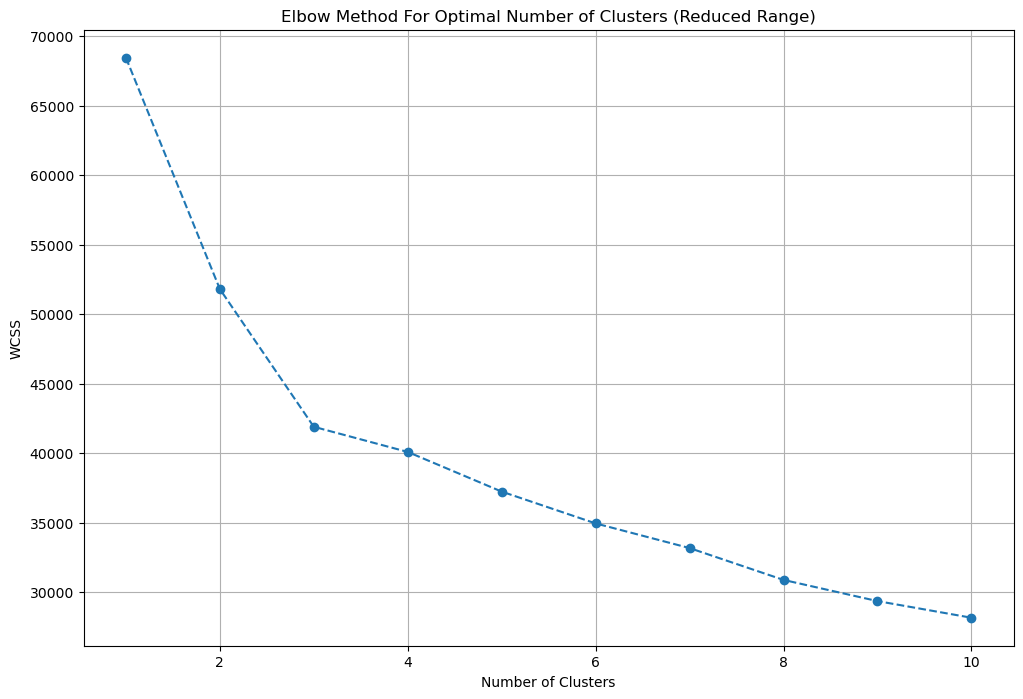

In [87]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [88]:
n_clusters = 3

# Fit the KMeans model
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(scaled_data)

# Predict the cluster assignments for each row
cluster_assignments = kmeans.predict(scaled_data)

In [89]:
df = df.iloc[:,:-18]

In [90]:
df['furnishing_type'] = cluster_assignments

In [91]:
df.sample(5)[['furnishDetails','furnishing_type']]
# 0 -> unfurnished
# 1 -> semifurnished
# 2 -> furnished

,furnishDetails,furnishing_type
2702,[],0
2606,"['5 AC', '1 Modular Kitchen', 'No Bed', 'No Ch...",0
3229,[],0
426,"['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '1 Ge...",2
113,"['1 Exhaust Fan', '4 Geyser', '1 Stove', '1 Mi...",2


In [92]:
#features 
df[['society','features']].sample(5)

,society,features
1744,nul,"['Security / Fire Alarm', 'Feng Shui / Vaastu ..."
1110,not applicable,NaN
3447,gls avenue 51,NaN
2458,signature global orchard avenue,"['Security / Fire Alarm', 'Lift(s)', 'Maintena..."
1502,umang winter hills,"['Feng Shui / Vaastu Compliant', 'Security / F..."


In [93]:
df['features'].isnull().sum()

np.int64(635)

In [95]:
import pandas as pd
app_df = pd.read_csv('appartments.csv')
app_df.head(2)

,PropertyName,PropertySubName,NearbyLocations,LocationAdvantages,Link,PriceDetails,TopFacilities
0,Smartworld One DXP,"2, 3, 4 BHK Apartment in Sector 113, Gurgaon","['Bajghera Road', 'Palam Vihar Halt', 'DPSG Pa...","{'Bajghera Road': '800 Meter', 'Palam Vihar Ha...",https://www.99acres.com/smartworld-one-dxp-sec...,"{'2 BHK': {'building_type': 'Apartment', 'area...","['Swimming Pool', 'Salon', 'Restaurant', 'Spa'..."
1,M3M Crown,"3, 4 BHK Apartment in Sector 111, Gurgaon","['DPSG Palam Vihar Gurugram', 'The NorthCap Un...","{'DPSG Palam Vihar Gurugram': '1.4 Km', 'The N...",https://www.99acres.com/m3m-crown-sector-111-g...,"{'3 BHK': {'building_type': 'Apartment', 'area...","['Bowling Alley', 'Mini Theatre', 'Manicured G..."


In [96]:
app_df['PropertyName'] = app_df['PropertyName'].str.lower()

In [97]:
temp_df = df[df['features'].isnull()]

In [98]:
temp_df.shape

(635, 26)

In [99]:
x = temp_df.merge(app_df,left_on='society',right_on='PropertyName',how='left')['TopFacilities']

In [100]:
df.loc[temp_df.index,'features'] = x.values

In [101]:
df['features'].isnull().sum()

np.int64(481)

In [102]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast

In [103]:
# Convert the string representation of lists in the 'features' column to actual lists
df['features_list'] = df['features'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) and x.startswith('[') else [])

# Use MultiLabelBinarizer to convert the features list into a binary matrix
mlb = MultiLabelBinarizer()
features_binary_matrix = mlb.fit_transform(df['features_list'])

# Convert the binary matrix into a DataFrame
features_binary_df = pd.DataFrame(features_binary_matrix, columns=mlb.classes_)

In [104]:
features_binary_df.sample(5)

,24/7 Power Backup,24/7 Water Supply,24x7 Security,ATM,Aerobics Centre,Air Hockey,Airy Rooms,Amphitheatre,Automated Car Wash,Badminton Court,Bank Attached Property,Banquet Hall,Bar/Chill-Out Lounge,Barbecue,Basketball Court,Beach Volley Ball Court,Billiards,Bowling Alley,Bus Shelter,Business Lounge,CCTV Camera Security,Cafeteria,Car Parking,Car wash area,Card Room,Centrally Air Conditioned,Changing Area,Children's Play Area,Cigar Lounge,Clinic,Club House,Club house / Community Center,Community Hall,Concierge Service,Conference room,Creche/Day care,Cricket Pitch,Doctor on Call,Earthquake Resistant,Entrance Lobby,False Ceiling Lighting,Feng Shui / Vaastu Compliant,Fire Fighting Systems,Fitness Centre / GYM,Flower Garden,Food Court,Foosball,Football,Fountain,Gated Community,Gazebo,Golf Course,Grocery Shop,Gymnasium,High Ceiling Height,High Speed Elevators,Infinity Pool,Intercom Facility,Internal Street Lights,Internet/wi-fi connectivity,Jacuzzi,Jogging Track,Landscape Garden,Laundry,Lawn Tennis Court,Library,Lift(s),Lounge,Low Density Society,Maintenance Staff,Manicured Garden,Medical Centre,Milk Booth,Mini Theatre,Multipurpose Court,Multipurpose Hall,Natural Light,Natural Pond,No open drainage around,Park,Party Lawn,Pergola,Piped Gas,Piped-gas,Pool Table,Power Back up Lift,Power Back-up,Private Garden / Terrace,Property Staff,RO System,Rain Water Harvesting,Reading Lounge,Recently Renovated,Reflexology Park,Restaurant,Salon,Sauna,School,Security / Fire Alarm,Security Personnel,Separate entry for servant room,Sewage Treatment Plant,Shopping Centre,Skating Rink,Solar Lighting,Solar Water Heating,Spa,Spacious Interiors,Squash Court,Steam Room,Sun Deck,Swimming Pool,Temple,Terrace Garden,Theatre,Toddler Pool,Valet Parking,Vastu Compliant,Video Door Security,Visitor Parking,Visitors Parking,Volley Ball Court,Waiting Lounge,Waste Disposal,Water Softener Plant,Water Storage,Water purifier,Water softening plant,Wi-Fi Connectivity,Yoga/Meditation Area
709,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
46,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1244,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0
3394,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0
1279,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0


In [105]:
features_binary_df.shape

(3803, 130)

In [106]:
wcss_reduced = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(features_binary_df)
    wcss_reduced.append(kmeans.inertia_)

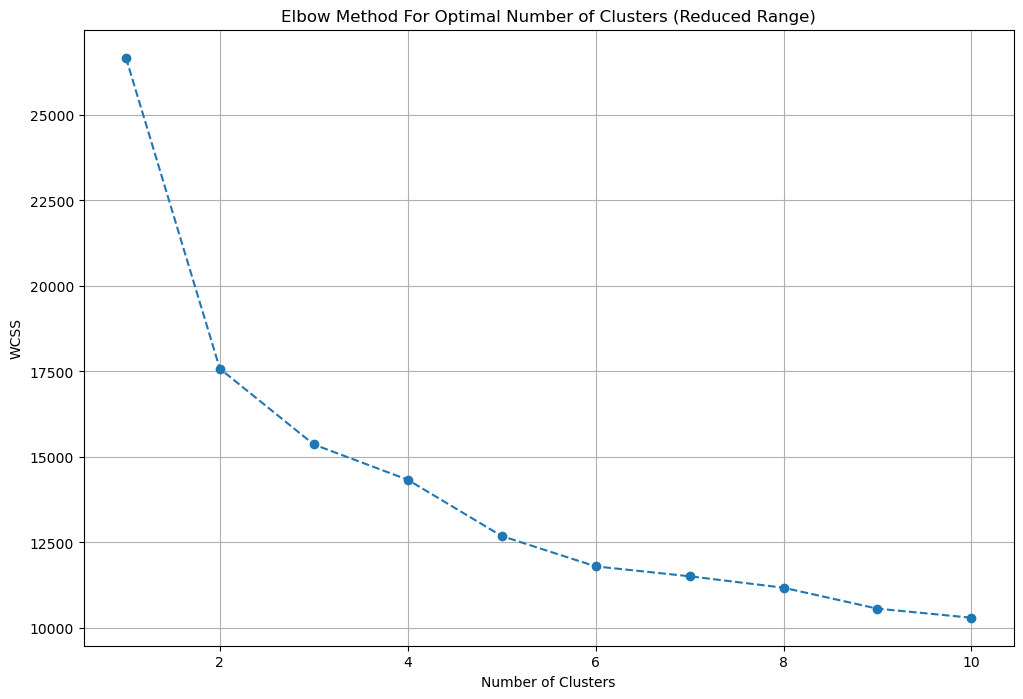

In [107]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(range(1,11), wcss_reduced, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal Number of Clusters (Reduced Range)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [109]:
# Define the weights for each feature as provided
# Assigning weights based on perceived luxury contribution
weights = {
    '24/7 Power Backup': 8,
    '24/7 Water Supply': 4,
    '24x7 Security': 7,
    'ATM': 4,
    'Aerobics Centre': 6,
    'Airy Rooms': 8,
    'Amphitheatre': 7,
    'Badminton Court': 7,
    'Banquet Hall': 8,
    'Bar/Chill-Out Lounge': 9,
    'Barbecue': 7,
    'Basketball Court': 7,
    'Billiards': 7,
    'Bowling Alley': 8,
    'Business Lounge': 9,
    'CCTV Camera Security': 8,
    'Cafeteria': 6,
    'Car Parking': 6,
    'Card Room': 6,
    'Centrally Air Conditioned': 9,
    'Changing Area': 6,
    "Children's Play Area": 7,
    'Cigar Lounge': 9,
    'Clinic': 5,
    'Club House': 9,
    'Concierge Service': 9,
    'Conference room': 8,
    'Creche/Day care': 7,
    'Cricket Pitch': 7,
    'Doctor on Call': 6,
    'Earthquake Resistant': 5,
    'Entrance Lobby': 7,
    'False Ceiling Lighting': 6,
    'Feng Shui / Vaastu Compliant': 5,
    'Fire Fighting Systems': 8,
    'Fitness Centre / GYM': 8,
    'Flower Garden': 7,
    'Food Court': 6,
    'Foosball': 5,
    'Football': 7,
    'Fountain': 7,
    'Gated Community': 7,
    'Golf Course': 10,
    'Grocery Shop': 6,
    'Gymnasium': 8,
    'High Ceiling Height': 8,
    'High Speed Elevators': 8,
    'Infinity Pool': 9,
    'Intercom Facility': 7,
    'Internal Street Lights': 6,
    'Internet/wi-fi connectivity': 7,
    'Jacuzzi': 9,
    'Jogging Track': 7,
    'Landscape Garden': 8,
    'Laundry': 6,
    'Lawn Tennis Court': 8,
    'Library': 8,
    'Lounge': 8,
    'Low Density Society': 7,
    'Maintenance Staff': 6,
    'Manicured Garden': 7,
    'Medical Centre': 5,
    'Milk Booth': 4,
    'Mini Theatre': 9,
    'Multipurpose Court': 7,
    'Multipurpose Hall': 7,
    'Natural Light': 8,
    'Natural Pond': 7,
    'Park': 8,
    'Party Lawn': 8,
    'Piped Gas': 7,
    'Pool Table': 7,
    'Power Back up Lift': 8,
    'Private Garden / Terrace': 9,
    'Property Staff': 7,
    'RO System': 7,
    'Rain Water Harvesting': 7,
    'Reading Lounge': 8,
    'Restaurant': 8,
    'Salon': 8,
    'Sauna': 9,
    'Security / Fire Alarm': 9,
    'Security Personnel': 9,
    'Separate entry for servant room': 8,
    'Sewage Treatment Plant': 6,
    'Shopping Centre': 7,
    'Skating Rink': 7,
    'Solar Lighting': 6,
    'Solar Water Heating': 7,
    'Spa': 9,
    'Spacious Interiors': 9,
    'Squash Court': 8,
    'Steam Room': 9,
    'Sun Deck': 8,
    'Swimming Pool': 8,
    'Temple': 5,
    'Theatre': 9,
    'Toddler Pool': 7,
    'Valet Parking': 9,
    'Video Door Security': 9,
    'Visitor Parking': 7,
    'Water Softener Plant': 7,
    'Water Storage': 7,
    'Water purifier': 7,
    'Yoga/Meditation Area': 7
}
# Calculate luxury score for each row
luxury_score = features_binary_df[list(weights.keys())].multiply(list(weights.values())).sum(axis=1)

In [110]:
df['luxury_score'] = luxury_score

In [111]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,floorNum,facing,agePossession,nearbyLocations,furnishDetails,features,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,features_list,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,"pooja room,study room,servant room,store room",3.0,East,Moderately Old,"['Iffco chowk metro station', 'Huda city centr...",[],"['Private Garden / Terrace', 'Water purifier',...",house,NaN,5490.0,NaN,1,1,1,1,0,0,"[Private Garden / Terrace, Water purifier, Fal...",76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,not availaible,1st of 1 Floors,NaN,Undefined,"['Metro Station', 'Gyanchand Market', 'Rajiv C...","['1 Light', 'No AC', 'No Bed', 'No Chimney', '...",NaN,flat,NaN,602.0,NaN,0,0,0,0,0,0,[],0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,not availaible,4th of 19 Floors,NaN,Relatively New,"['Huda Metro Station', 'Sector Road', 'Delhi-J...","['2 Wardrobe', '4 Fan', '1 Exhaust Fan', '2 Ge...","['Feng Shui / Vaastu Compliant', 'Security / F...",flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,"[Feng Shui / Vaastu Compliant, Security / Fire...",56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,not availaible,8th of 14 Floors,NaN,Relatively New,"['JMS Marine Square Mall', 'Dwarka Expressway'...",[],"['Power Back-up', 'Intercom Facility', 'Lift(s...",flat,1650.0,NaN,1022.58,0,0,0,0,0,0,"[Power Back-up, Intercom Facility, Lift(s), Sw...",46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,servant room,2nd of 17 Floors,South-East,Moderately Old,"['Sector 55-56 Rapid Metro Station', 'HUB 66',...","['6 Wardrobe', '5 Fan', '1 Exhaust Fan', '4 Ge...","['Security / Fire Alarm', 'Power Back-up', 'In...",flat,2200.0,NaN,NaN,0,1,0,0,0,2,"[Security / Fire Alarm, Power Back-up, Interco...",123


In [112]:
# cols to drop -> nearbyLocations,furnishDetails, features,features_list, additionalRoom
df.drop(columns=['nearbyLocations','furnishDetails','features','features_list','additionalRoom'],inplace=True)

In [113]:
df.sample(5)

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
935,independent,6.46,sector 14,18889.0,3420.00,Plot area 380(317.73 sq.m.)Built Up area: 380 ...,5,5,2,3.0,East,Moderately Old,house,NaN,380.0,300.0,1,1,0,1,0,2,27
658,dlf city plot phase 4,13.00,sector 28,1992.0,65261.00,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,house,NaN,NaN,7250.0,0,0,0,0,0,0,0
2557,parsvnath green ville,2.50,sector 48,12820.0,1950.08,Carpet area: 1950 (181.16 sq.m.),4,5,3,1st of 19 Floors,South-East,Moderately Old,flat,NaN,NaN,1950.0,0,0,0,0,1,2,49
1245,shyamkunj ashok vihar pahse 2,0.30,sector 3 phase 2,4444.0,675.07,Carpet area: 675 (62.71 sq.m.),2,2,1,1st of 4 Floors,East,Relatively New,flat,NaN,NaN,675.0,0,0,0,0,0,0,21
2195,international city by sobha phase 2,6.50,sector 109,12037.0,5400.00,Plot area 5400(501.68 sq.m.),4,4,3+,1.0,North-East,New Property,house,NaN,5400.0,NaN,0,1,0,0,0,2,160


In [ ]:
df.shape

In [114]:
df.to_csv('gurgaon_properties_cleaned_v2.csv',index=False)